### Task 1: One-Way ANOVA
Split the outcome variable into separate arrays (or use a groupby), one per level of the grouping variable.

Run a one-way ANOVA using scipy.stats.f_oneway.

Record the F-statistic and p-value.

In a markdown cell, interpret the result:
        State the null and alternative hypotheses in plain language.
        Based on the p-value (use α = 0.05), do you reject or fail to reject the null?
        What does the F-statistic tell you about the ratio of between-group to within-group variance?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats

penguins = sns.load_dataset("penguins")
penguins.info()
penguins.describe()
penguins['species'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [2]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
penguins_clean = penguins[['species', 'body_mass_g']].dropna()

In [7]:
penguins_clean['species'] = penguins_clean['species'].str.strip()

In [8]:
penguins_clean.isnull().sum()

species        0
body_mass_g    0
dtype: int64

In [12]:
adelie=penguins_clean[penguins_clean["species"]=="Adelie"]["body_mass_g"]
chinstrap =penguins_clean[penguins_clean["species"]=="Chinstrap"]["body_mass_g"]
gentoo=penguins_clean[penguins_clean["species"]=="Gentoo"]["body_mass_g"]

In [13]:
F_stat, p_value = stats.f_oneway(adelie, chinstrap, gentoo)

print("F-statistic:", F_stat)
print("p-value:", p_value)

F-statistic: 343.626275205481
p-value: 2.8923681333773435e-82


- State the null and alternative hypotheses in plain language.
- Based on the p-value (use α = 0.05), do you reject or fail to reject the null?
- What does the F-statistic tell you about the ratio of between-group to within-group variance?

#### Null and Alternative Hypotheses (Plain Language)**

- **Null hypothesis (H₀):** The average body mass of all penguin species (Adelie, Chinstrap, Gentoo) is the same.  
- **Alternative hypothesis (H₁):** At least one penguin species has a different average body mass.  

---

#### Decision Based on p-value (α = 0.05)**

- **p-value:** 2.89 × 10^-82  
- Since the p-value is much smaller than 0.05, we **reject the null hypothesis**.  
- ✅ Conclusion: There is a statistically significant difference in mean body mass between penguin species.  

---

#### Interpretation of F-statistic**

- The F-statistic represents the ratio of **between-group variance** to **within-group variance**.  
- A large F-value indicates that the differences between group means are much greater than the variability within each group.  
- In this case, the large F shows that **species differences explain a substantial portion of the variation in body mass**, not just random chance.

### Task 2: Check ANOVA Assumptions
ANOVA results are only reliable when two key assumptions hold. Test both here.

Homogeneity of variance (Levene's test):

Run scipy.stats.levene on the same groups.
Report the test statistic and p-value.
Interpret: is the equal-variance assumption reasonable?
Normality of residuals:

For each group, run the Shapiro-Wilk test (scipy.stats.shapiro).
Alternatively, compute the ANOVA residuals (observed − group mean) and run Shapiro-Wilk on the pooled residuals.
Create a Q-Q plot of the residuals (use scipy.stats.probplot or statsmodels.graphics.gofplots.qqplot).
In a markdown cell, summarize:
Do the residuals look approximately normal?
If either assumption is violated, what alternatives could you use (e.g., Welch's ANOVA, Kruskal-Wallis)?

In [14]:
from scipy.stats import levene

In [17]:
#step1
levene_stat, levene_p = levene( adelie, chinstrap, gentoo)
print("Levene Test Statistic:", levene_stat)
print("Levene Test p-value:", levene_p)

Levene Test Statistic: 5.12025099751946
Levene Test p-value: 0.006445082805324008


##### Homogeneity of Variance (Levene's Test)

**Test Purpose:**  
Levene’s test checks whether the variances of the groups are equal — one of the key assumptions of ANOVA.

**Null hypothesis (H₀):** All groups have equal variances.  
**Alternative hypothesis (H₁):** At least one group has a different variance.

**Levene Test Results:**  
- Test Statistic = *[5.12025099]*  
- p-value = 0.0064

**Interpretation:**  
- Since p-value < 0.05, we **reject the null hypothesis**.  
-  This indicates that the variances of body mass across penguin species are **not equal**.  

**Practical implication:**  
- The equal-variance assumption for standard one-way ANOVA is **violated**.  
- Recommended alternatives: **Welch’s ANOVA** (robust to unequal variances) or **Kruskal-Wallis test** (non-parametric approach).

In [19]:
#step2 Step 2: a)Normality of Residuals (Shapiro-Wilk Test + Q-Q Plot)
penguins_clean["group_mean"]= penguins_clean.groupby("species")['body_mass_g'].transform('mean')
penguins_clean["residuals"]= penguins_clean['body_mass_g'] - penguins_clean['group_mean']

In [20]:
residuals = penguins_clean['residuals']

In [21]:
#b) Shapiro-Wilk test
from scipy.stats import shapiro

shapiro_stat, shapiro_p = shapiro(residuals)
print("Shapiro-Wilk Test Statistic:", shapiro_stat)
print("Shapiro-Wilk Test p-value:", shapiro_p)

Shapiro-Wilk Test Statistic: 0.9916575409473664
Shapiro-Wilk Test p-value: 0.05118326913958188


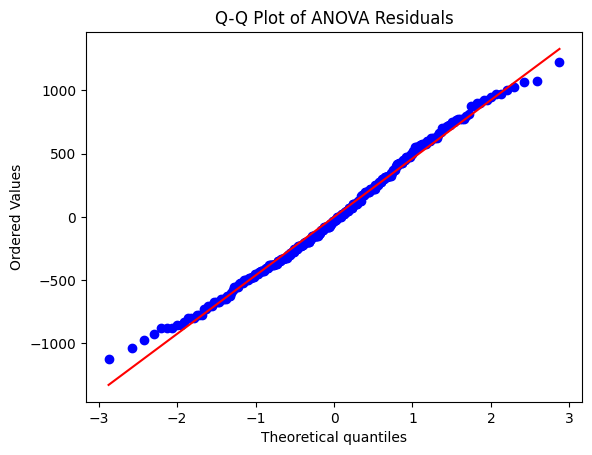

In [22]:
#Q-Q plot
import matplotlib.pyplot as plt
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of ANOVA Residuals")
plt.show()

In a markdown cell, summarize:
- Do the residuals look approximately normal?
- If either assumption is violated, what alternatives could you use (e.g., Welch's ANOVA, Kruskal-Wallis)?

### Normality of Residuals

**Test Purpose:**  
Shapiro-Wilk test and Q-Q plot check whether the residuals from the ANOVA model are approximately normally distributed — another key assumption of ANOVA.

**Null hypothesis (H₀):** Residuals are normally distributed.  
**Alternative hypothesis (H₁):** Residuals are not normally distributed.

**Shapiro-Wilk Test Results:**  
- Test Statistic (W) = *[0.9916575409473664]*  
- p-value = 0.0512

**Interpretation:**  
- Since p-value > 0.05, we **fail to reject the null hypothesis**.  
- Residuals are approximately normally distributed.  

**Q-Q Plot:**  
- The residuals closely follow the red reference line in the Q-Q plot.  
- This visually confirms that the residuals are roughly normal, supporting the ANOVA assumption.  

**Practical Implication:**  
- The normality assumption for one-way ANOVA is **reasonably satisfied**, so the ANOVA results are valid with respect to residual normality.

### Task 3: Tukey HSD Post-Hoc Comparisons
The overall ANOVA F-test tells you that at least one group differs, but not which groups differ. Post-hoc tests fill that gap.

Run Tukey's HSD test using statsmodels.stats.multicomp.pairwise_tukeyhsd.
Print the results table showing each pairwise comparison, the mean difference, the confidence interval, and the reject/fail-to-reject decision.
Create a mean plot with confidence intervals (Tukey's HSD provides these) to visualize which groups overlap.
In a markdown cell, answer:
Which specific group pairs have significantly different means?
Which pairs are not significantly different?
Do the confidence intervals help you understand the practical size of the differences?

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2  meandiff p-adj    lower     upper   reject
--------------------------------------------------------------
   Adelie Chinstrap   32.426 0.8807 -126.5002  191.3522  False
   Adelie    Gentoo 1375.354    0.0 1243.1786 1507.5294   True
Chinstrap    Gentoo 1342.928    0.0  1178.481  1507.375   True
--------------------------------------------------------------


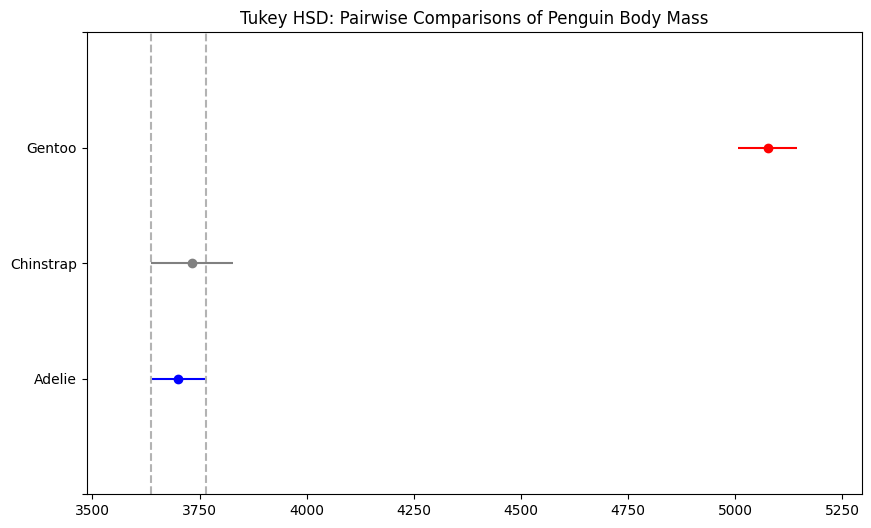

C:\Users\Asus\AppData\Local\Temp\ipykernel_26408\775698889.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=penguins_clean, x='species', y='body_mass_g', capsize=0.1, join=False)


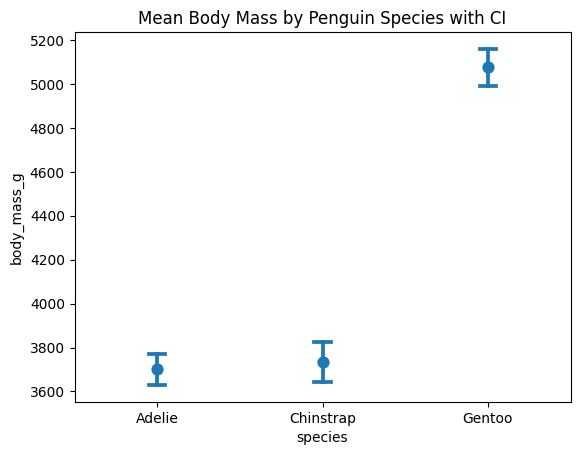

In [23]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

# Run Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=penguins_clean['body_mass_g'],
                          groups=penguins_clean['species'],
                          alpha=0.05)

# Print the results table
print(tukey.summary())

# Optional: visualize the group means with confidence intervals
tukey.plot_simultaneous(comparison_name='Adelie')
plt.title("Tukey HSD: Pairwise Comparisons of Penguin Body Mass")
plt.show()

# Alternative: mean plot with seaborn
sns.pointplot(data=penguins_clean, x='species', y='body_mass_g', capsize=0.1, join=False)
plt.title("Mean Body Mass by Penguin Species with CI")
plt.show()

In a markdown cell, answer:

Which specific group pairs have significantly different means?

Which pairs are not significantly different?

Do the confidence intervals help you understand the practical size of the differences?

### Task 3: Tukey HSD Post-Hoc Comparisons

**Purpose:**  
The overall ANOVA F-test indicated that at least one penguin species has a different mean body mass, but it does not tell us which species differ. Tukey HSD (Honestly Significant Difference) test performs **pairwise comparisons** to identify specifically which groups have statistically significant differences.

**Tukey HSD Results:**

| Group 1   | Group 2   | Mean Diff (g) | p-adj  | Reject H₀? | Interpretation |
|-----------|-----------|---------------|--------|------------|----------------|
| Adelie    | Chinstrap | 32.43         | 0.8807 | False      | No significant difference; mean body mass is similar. CI = [-126.50, 191.35] includes 0. |
| Adelie    | Gentoo    | 1375.35       | 0.0    | True       | Statistically significant; Gentoo has much higher mean body mass. CI = [1243.18, 1507.53] excludes 0. |
| Chinstrap | Gentoo    | 1342.93       | 0.0    | True       | Statistically significant; Gentoo has much higher mean body mass. CI = [1178.48, 1507.38] excludes 0. |

**Interpretation:**  
- **Gentoo penguins** differ significantly from both Adelie and Chinstrap in mean body mass.  
- **Adelie and Chinstrap** do **not** differ significantly.  
- Confidence intervals help us understand the **practical size of the differences**:
  - Gentoo differences > 1000g → both statistically and practically significant.  
  - Adelie-Chinstrap difference ≈ 32g → not practically significant.

**Visual Insights:**  
- Mean plot with confidence intervals confirms statistical results:
  - Gentoo intervals are separate from the other species → clear difference.
  - Adelie and Chinstrap intervals overlap → no significant difference.